In [22]:
print(os.listdir(DATASET_PATH))

['A', 'B', 'C', 'F', 'L', 'O', 'Q', 'V']


In [2]:
import numpy as np
print("NumPy:", np.__version__)

import tensorflow as tf
print("TensorFlow:", tf.__version__)

import cv2
print("OpenCV:", cv2.__version__)

import mediapipe as mp
print("MediaPipe:", mp.__version__)
print(hasattr(mp, "solutions"))

NumPy: 1.26.4

TensorFlow: 2.15.0
OpenCV: 4.13.0
MediaPipe: 0.10.10
True


In [21]:
import os, cv2, random, pickle
import numpy as np
import tensorflow as tf
import mediapipe as mp
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

DATASET_PATH = "debas"
selected_classes = ["A", "B", "C", "Q", "V", "L", "Y", "F", "O"]
MAX_IMAGES_PER_CLASS = 500
EPOCHS = 20

In [24]:
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

X, y = [], []

def extract_landmarks(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb)

    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]
    wrist = hand.landmark[0]

    landmarks = []
    for lm in hand.landmark:
        landmarks.extend([lm.x - wrist.x, lm.y - wrist.y, lm.z - wrist.z])

    return landmarks

for class_id, cls in enumerate(selected_classes):
    folder = os.path.join(DATASET_PATH, cls)
    images = os.listdir(folder)
    images = random.sample(images, min(len(images), MAX_IMAGES_PER_CLASS))

    print("Processing:", cls)

    for img_name in images:
        img = cv2.imread(os.path.join(folder, img_name))
        if img is None:
            continue

        lm = extract_landmarks(img)
        if lm is not None:
            X.append(lm)
            y.append(class_id)

hands.close()

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X:", X.shape)
print("y:", y.shape)

Processing: A
Processing: B
Processing: C
Processing: Q
Processing: V
Processing: L
Processing: Y
Processing: F
Processing: O
X: (3238, 63)
y: (3238,)


In [25]:
import os
import numpy as np
import scipy.io.wavfile as wav

os.makedirs("sounds", exist_ok=True)

sample_rate = 44100

def create_tone(filename, frequency, duration=0.35):
    t = np.linspace(0, duration, int(sample_rate * duration), False)
    wave = np.sin(2 * np.pi * frequency * t)
    audio = (wave * 32767).astype(np.int16)
    wav.write(filename, sample_rate, audio)

note_frequency = {
    "A": 440.00,   # A
    "B": 493.88,   # B
    "C": 261.63,   # C
    "V": 293.66,   # D
    "Q": 329.63,   # E
    "L": 349.23,   # F
    "Y": 392.00,   # G
}

for gesture, freq in note_frequency.items():
    path = f"sounds/{gesture}.wav"

    if not os.path.exists(path):
        create_tone(path, freq)
        print("Created:", path)
    else:
        print("Already exists:", path)

print("Sounds ready.")

Already exists: sounds/A.wav
Already exists: sounds/B.wav
Already exists: sounds/C.wav
Already exists: sounds/V.wav
Already exists: sounds/Q.wav
Already exists: sounds/L.wav
Already exists: sounds/Y.wav
Sounds ready.


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

landmark_model = models.Sequential([
    layers.Input(shape=(63,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(selected_classes), activation="softmax")
])

landmark_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

landmark_history = landmark_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=32,
    shuffle=True
)

Epoch 1/20
81/81 [==============================] - 1s 3ms/step - loss: 1.7640 - accuracy: 0.4351 - val_loss: 1.2247 - val_accuracy: 0.7623
Epoch 2/20
81/81 [==============================] - 0s 2ms/step - loss: 0.9914 - accuracy: 0.7459 - val_loss: 0.6461 - val_accuracy: 0.8873
Epoch 3/20
81/81 [==============================] - 0s 2ms/step - loss: 0.6250 - accuracy: 0.8529 - val_loss: 0.3977 - val_accuracy: 0.9167
Epoch 4/20
81/81 [==============================] - 0s 2ms/step - loss: 0.4399 - accuracy: 0.9058 - val_loss: 0.2583 - val_accuracy: 0.9583
Epoch 5/20
81/81 [==============================] - 0s 2ms/step - loss: 0.3186 - accuracy: 0.9313 - val_loss: 0.1844 - val_accuracy: 0.9753
Epoch 6/20
81/81 [==============================] - 0s 2ms/step - loss: 0.2573 - accuracy: 0.9413 - val_loss: 0.1379 - val_accuracy: 0.9815
Epoch 7/20
81/81 [==============================] - 0s 2ms/step - loss: 0.1992 - accuracy: 0.9544 - val_loss: 0.1164 - val_accuracy: 0.9799
Epoch 8/20
81/81 [==

In [27]:
landmark_model.save("asl_landmark_model.keras")

with open("asl_landmark_classes.txt", "w") as f:
    for cls in selected_classes:
        f.write(cls + "\n")

with open("landmark_history.pkl", "wb") as f:
    pickle.dump(landmark_history.history, f)

print("Landmark model saved.")

Landmark model saved.


In [28]:
#Demo
import os, cv2, time
import numpy as np
import tensorflow as tf
import pygame
import mediapipe as mp

In [29]:
model = tf.keras.models.load_model("asl_landmark_model.keras")

with open("asl_landmark_classes.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]

pygame.mixer.init()

sounds = {}
for cls in class_names:
    path = f"sounds/{cls}.wav"
    if os.path.exists(path):
        sounds[cls] = pygame.mixer.Sound(path)

print("Loaded:", class_names)

Loaded: ['A', 'B', 'C', 'Q', 'V', 'L', 'Y', 'F', 'O']


In [30]:
gesture_to_note = {
    "A": "A",
    "B": "B",
    "C": "C",
    "L": "F",
    "Y": "G",
    "V": "D",
    "Q": "E",
    "F": "REST",
    "O": "TEMPO"
}

white_keys = ["A", "B", "C", "D", "E", "F", "G"]

def draw_piano(active_gesture=None, tempo_bpm=120):
    active_note = gesture_to_note.get(active_gesture, None)

    white_w = 90
    white_h = 230
    black_w = 55
    black_h = 140

    piano = np.ones((340, white_w * len(white_keys), 3), dtype=np.uint8) * 230

    for i, note in enumerate(white_keys):
        x1 = i * white_w
        x2 = x1 + white_w

        color = (255, 255, 255)
        if note == active_note:
            color = (120, 255, 120)

        cv2.rectangle(piano, (x1, 30), (x2, 30 + white_h), color, -1)
        cv2.rectangle(piano, (x1, 30), (x2, 30 + white_h), (0, 0, 0), 2)
        cv2.putText(piano, note, (x1 + 30, 245),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

    black_keys = {
        "C#": 0.65,
        "D#": 1.65,
        "F#": 3.65,
        "G#": 4.65,
        "A#": 5.65
    }

    for note, pos in black_keys.items():
        x_center = int(pos * white_w)
        x1 = x_center - black_w // 2
        x2 = x_center + black_w // 2
        cv2.rectangle(piano, (x1, 30), (x2, 30 + black_h), (20, 20, 20), -1)

    cv2.putText(piano, f"Tempo: {tempo_bpm} BPM", (20, 320),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

    return piano


def extract_landmarks_from_results(results):
    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]
    wrist = hand.landmark[0]

    landmarks = []
    for lm in hand.landmark:
        landmarks.extend([lm.x - wrist.x, lm.y - wrist.y, lm.z - wrist.z])

    return np.array(landmarks, dtype=np.float32)


def get_pinch_distance(hand_landmarks):
    thumb_tip = hand_landmarkselandmark[4]

In [31]:
def extract_landmarks_from_results(results):
    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]
    wrist = hand.landmark[0]

    landmarks = []
    for lm in hand.landmark:
        landmarks.extend([lm.x - wrist.x, lm.y - wrist.y, lm.z - wrist.z])

    return np.array(landmarks, dtype=np.float32)


def get_pinch_distance(hand_landmarks):
    thumb_tip = hand_landmarks.landmark[4]
    index_tip = hand_landmarks.landmark[8]

    dx = thumb_tip.x - index_tip.x
    dy = thumb_tip.y - index_tip.y

    return np.sqrt(dx * dx + dy * dy)

In [32]:
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)

cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

prediction_buffer = []
buffer_size = 12

last_prediction = None
last_play_time = 0

tempo_bpm = 120
min_bpm = 60
max_bpm = 180

confidence_threshold = 0.90

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb)

    gesture = "No hand"
    confidence = 0.0
    active_key = None

    cooldown = 60 / tempo_bpm

    if results.multi_hand_landmarks:
        hand_landmarks = results.multi_hand_landmarks[0]
        mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        landmarks = extract_landmarks_from_results(results)

        if landmarks is not None:
            input_data = np.expand_dims(landmarks, axis=0)

            prediction = model.predict(input_data, verbose=0)[0]
            raw_class_id = np.argmax(prediction)

            prediction_buffer.append(raw_class_id)
            if len(prediction_buffer) > buffer_size:
                prediction_buffer.pop(0)

            stable_class_id = max(set(prediction_buffer), key=prediction_buffer.count)

            gesture = class_names[stable_class_id]
            confidence = prediction[stable_class_id]

            if confidence > confidence_threshold:
                if gesture == "O":
                    pinch = get_pinch_distance(hand_landmarks)

                    tempo_bpm = int(np.interp(
                        pinch,
                        [0.03, 0.20],
                        [min_bpm, max_bpm]
                    ))

                    tempo_bpm = max(min_bpm, min(max_bpm, tempo_bpm))
                    active_key = None

                elif gesture == "F":
                    active_key = None
                    last_prediction = gesture

                else:
                    active_key = gesture
                    now = time.time()

                    if gesture != last_prediction or now - last_play_time > cooldown:
                        if gesture in sounds:
                            sounds[gesture].play()

                        last_prediction = gesture
                        last_play_time = now
            else:
                last_prediction = None

    piano = draw_piano(active_key, tempo_bpm)
    piano = cv2.resize(piano, (frame.shape[1], 180))

    cv2.putText(frame, f"Gesture: {gesture} ({confidence:.2f})",
                (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1,
                (0, 255, 0), 2)

    if gesture == "O":
        cv2.putText(frame, "TEMPO MODE: pinch open/close",
                    (30, 90), cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, (0, 255, 255), 2)

    combined = np.vstack((frame, piano))
    cv2.imshow("ASL Landmark Piano", combined)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
hands.close()
cv2.destroyAllWindows()

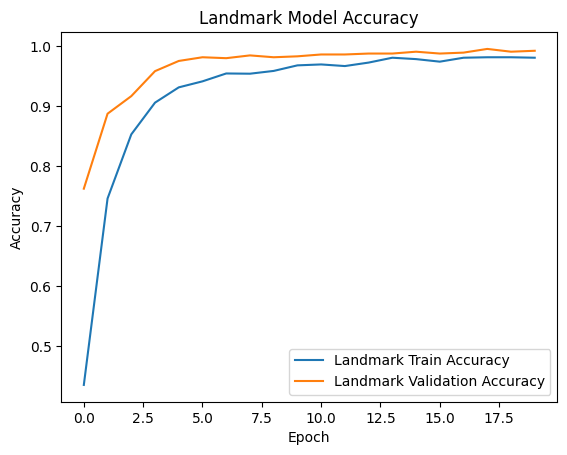

In [33]:
#Graphs - Landmark Model Accuracy
import pickle
import matplotlib.pyplot as plt

with open("landmark_history.pkl", "rb") as f:
    landmark_history_data = pickle.load(f)

plt.plot(landmark_history_data["accuracy"], label="Landmark Train Accuracy")
plt.plot(landmark_history_data["val_accuracy"], label="Landmark Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Landmark Model Accuracy")
plt.legend()
plt.show()

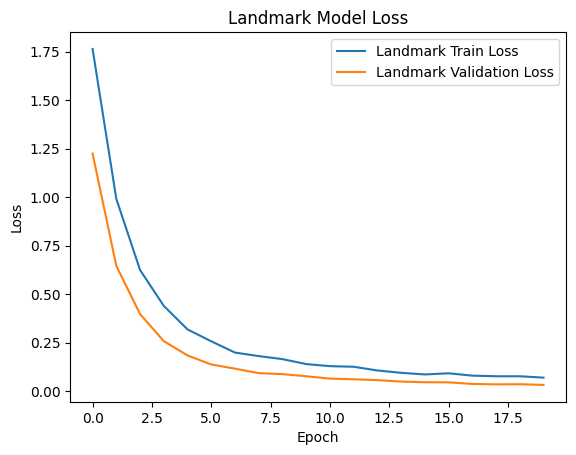

In [34]:
plt.plot(landmark_history_data["loss"], label="Landmark Train Loss")
plt.plot(landmark_history_data["val_loss"], label="Landmark Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Landmark Model Loss")
plt.legend()
plt.show()

21/21 [==============================] - 0s 1ms/step


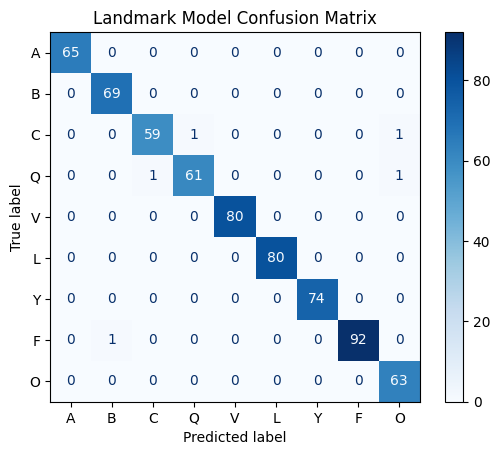

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_pred_probs = landmark_model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=selected_classes
)

disp.plot(cmap="Blues")
plt.title("Landmark Model Confusion Matrix")
plt.show()

In [36]:
import pickle

with open("landmark_history.pkl", "wb") as f:
    pickle.dump(landmark_history.history, f)

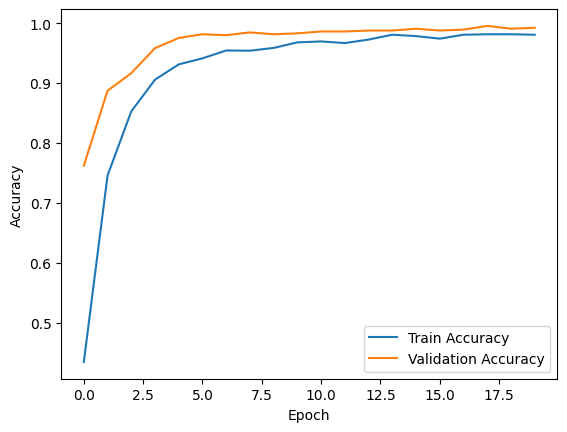

In [37]:
with open("landmark_history.pkl", "rb") as f:
    landmark_history_data = pickle.load(f)

plt.plot(landmark_history.history["accuracy"], label="Train Accuracy")
plt.plot(landmark_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

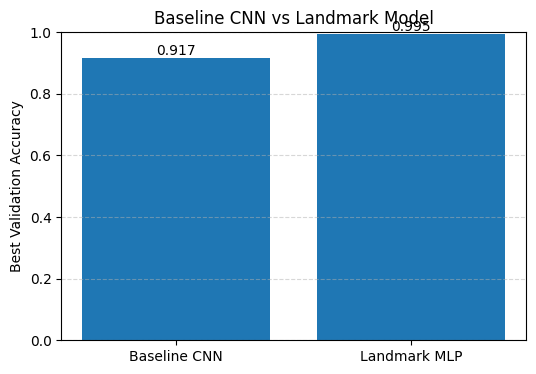

In [38]:
import matplotlib.pyplot as plt

# If CNN history not loaded, fallback to known value
if "cnn_history_data" in globals():
    cnn_best_val = max(cnn_history_data["val_accuracy"])
else:
    cnn_best_val = 0.9175   # your known CNN result

# If landmark history exists
if "landmark_history_data" in globals():
    landmark_best_val = max(landmark_history_data["val_accuracy"])
else:
    landmark_best_val = max(landmark_history.history["val_accuracy"])

models = ["Baseline CNN", "Landmark MLP"]
scores = [cnn_best_val, landmark_best_val]

plt.figure(figsize=(6,4))
bars = plt.bar(models, scores)

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center')

plt.ylabel("Best Validation Accuracy")
plt.title("Baseline CNN vs Landmark Model")
plt.ylim(0, 1)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()